#  Bayesian Tennis Pipeline

## Important Points
- **Strict temporal holdout**: example uses **Wimbledon 2023** as test and trains only on earlier matches
- **Stable player encoding** via **player IDs**
- **Dynamic BT identifiability** via **per-period centering**
- **Proper dynamic prediction** using each match's **own time period**
- **Covariates encoded safely** in symmetric pairwise format
- **Regularized frequentist BT baseline** for comparison

In [1]:
!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.1/384.1 kB 12.3 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
DATA_DIR = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/"
YEARS = list(range(2018, 2024))
TEST_TOURNAMENT = "Wimbledon"
TEST_YEAR = 2023
TIME_FREQ = "Q"               # quarter periods for dynamic model
MIN_MATCHES_PER_PLAYER = 8     # filter sparse players for stability
DRAWS = 800
TUNE = 800
CHAINS = 4
TARGET_ACCEPT = 0.92
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1) Data loading
Load Jeff Sackmann ATP match files and keep only the columns needed for the modeling pipeline.

In [3]:
# -----------------------------------------------------------------------------
# DATA LOADING
# -----------------------------------------------------------------------------
def load_atp_data(years: Iterable[int], data_dir: str) -> pd.DataFrame:
    """Load Jeff Sackmann ATP yearly CSV files and keep useful pre-match columns."""
    keep_cols = [
        "tourney_date", "tourney_id", "tourney_name", "tourney_level", "surface",
        "best_of", "round", "minutes",
        "winner_id", "winner_name", "winner_rank", "winner_rank_points", "winner_age", "winner_ht",
        "loser_id", "loser_name", "loser_rank", "loser_rank_points", "loser_age", "loser_ht",
    ]

    dfs = []
    for year in years:
        url = f"{data_dir}atp_matches_{year}.csv"
        df = pd.read_csv(url, low_memory=False)
        df["year"] = year
        missing = [c for c in keep_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing expected columns in {url}: {missing}")
        dfs.append(df[keep_cols + ["year"]].copy())

    data = pd.concat(dfs, ignore_index=True)
    data["tourney_date"] = pd.to_datetime(data["tourney_date"].astype(str), format="%Y%m%d")

    # Basic cleaning
    data = data.dropna(subset=["winner_id", "loser_id", "tourney_date", "surface"])
    data = data[data["winner_id"] != data["loser_id"]].copy()

    # Normalize surface names
    data["surface"] = data["surface"].astype(str).str.strip().str.capitalize()
    known_surfaces = {"Hard", "Clay", "Grass", "Carpet"}
    data.loc[~data["surface"].isin(known_surfaces), "surface"] = "Hard"

    # Useful numeric cleanup
    numeric_cols = [
        "winner_rank", "winner_rank_points", "winner_age", "winner_ht",
        "loser_rank", "loser_rank_points", "loser_age", "loser_ht", "best_of", "minutes"
    ]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Round ordering for optional use
    round_map = {
        "RR": 0, "BR": 1, "R128": 2, "R64": 3, "R32": 4, "R16": 5,
        "QF": 6, "SF": 7, "F": 8
    }
    data["round_num"] = data["round"].map(round_map).fillna(-1).astype(int)

    return data.sort_values("tourney_date").reset_index(drop=True)


## 2) Stable player encoding and filtering
Players are encoded using **ATP IDs**, not names.  
We also filter very sparse players to reduce instability.

In [4]:
# -----------------------------------------------------------------------------
# STABLE PLAYER ENCODING + FILTERING
# -----------------------------------------------------------------------------
def filter_players_by_min_matches(data: pd.DataFrame, min_matches: int = 8) -> pd.DataFrame:
    ids = pd.concat([data["winner_id"], data["loser_id"]]).astype("Int64")
    counts = ids.value_counts()
    keep_ids = set(counts[counts >= min_matches].index.astype(int))
    out = data[data["winner_id"].isin(keep_ids) & data["loser_id"].isin(keep_ids)].copy()
    return out.reset_index(drop=True)


@dataclass
class PlayerEncoding:
    player2idx: dict[int, int]
    idx2player_id: dict[int, int]
    idx2player_name: dict[int, str]


def encode_players_by_id(data: pd.DataFrame) -> tuple[pd.DataFrame, PlayerEncoding]:
    """Encode players using stable ATP IDs, not names."""
    players_w = data[["winner_id", "winner_name"]].rename(columns={"winner_id": "player_id", "winner_name": "player_name"})
    players_l = data[["loser_id", "loser_name"]].rename(columns={"loser_id": "player_id", "loser_name": "player_name"})
    players = pd.concat([players_w, players_l], ignore_index=True)
    players["player_id"] = players["player_id"].astype(int)
    players = players.drop_duplicates("player_id")

    player_ids = np.sort(players["player_id"].unique())
    player2idx = {pid: i for i, pid in enumerate(player_ids)}

    id_to_name = (
        players.groupby("player_id")["player_name"]
        .agg(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else str(s.name))
        .to_dict()
    )

    out = data.copy()
    out["winner_id"] = out["winner_id"].astype(int)
    out["loser_id"] = out["loser_id"].astype(int)
    out["winner_idx"] = out["winner_id"].map(player2idx)
    out["loser_idx"] = out["loser_id"].map(player2idx)

    enc = PlayerEncoding(
        player2idx=player2idx,
        idx2player_id={i: pid for pid, i in player2idx.items()},
        idx2player_name={i: id_to_name.get(pid, str(pid)) for pid, i in player2idx.items()},
    )
    return out, enc

## 3) Time indexing and strict out-of-time split
The test set is a **single future tournament**.  
Training uses only matches that happened **before the held-out event begins**.

In [5]:
# -----------------------------------------------------------------------------
# TIME INDEXING + SPLIT
# -----------------------------------------------------------------------------
def assign_time_periods(data: pd.DataFrame, freq: str = "Q") -> tuple[pd.DataFrame, pd.PeriodIndex]:
    out = data.copy()
    out["period_label"] = out["tourney_date"].dt.to_period(freq)
    periods = pd.period_range(out["period_label"].min(), out["period_label"].max(), freq=freq)
    period_map = {p: i for i, p in enumerate(periods)}
    out["period"] = out["period_label"].map(period_map).astype(int)
    return out, periods


def temporal_tournament_split(
    data: pd.DataFrame,
    test_tournament: str,
    test_year: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    """
    Strictly temporal split:
    test = only matches from the specified tournament in the specified year
    train = matches strictly before the first date of that event
    """
    test_mask = (data["tourney_name"] == test_tournament) & (data["year"] == test_year)
    test_df = data.loc[test_mask].copy()
    if test_df.empty:
        raise ValueError(f"No matches found for test event: {test_tournament} {test_year}")

    cutoff_date = test_df["tourney_date"].min()
    train_df = data.loc[data["tourney_date"] < cutoff_date].copy()

    # Keep only matches whose players are known in training.
    known_players = set(pd.concat([train_df["winner_idx"], train_df["loser_idx"]]).unique())
    test_df = test_df[test_df["winner_idx"].isin(known_players) & test_df["loser_idx"].isin(known_players)].copy()

    if test_df.empty:
        raise ValueError("After removing unseen players, the held-out tournament has no usable matches.")

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True), cutoff_date

## 4) Pairwise dataset construction and covariate encoding

Each original match is expanded into two rows:

- `(p1 = winner, p2 = loser, y = 1)`
- `(p1 = loser, p2 = winner, y = 0)`

This makes the covariate design consistent with the BT/logistic likelihood.

### Encoded covariates
- `surf_clay`, `surf_grass`, `surf_carpet` with **Hard** as reference
- `best_of`
- `rank_diff`
- `rank_points_diff`
- `age_diff`
- `height_diff`

In [6]:
# -----------------------------------------------------------------------------
# PAIRWISE EXPANSION WITH COVARIATE ENCODING
# -----------------------------------------------------------------------------
def _safe_fill_by_median(train_vals: pd.Series, vals: pd.Series) -> pd.Series:
    med = train_vals.dropna().median()
    if pd.isna(med):
        med = 0.0
    return vals.fillna(med)


def add_surface_dummies(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["surf_clay"] = (out["surface"] == "Clay").astype(int)
    out["surf_grass"] = (out["surface"] == "Grass").astype(int)
    out["surf_carpet"] = (out["surface"] == "Carpet").astype(int)
    # Hard is the reference category.
    return out


def build_pairwise_dataset(raw_df: pd.DataFrame, train_reference_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    """
    Convert winner/loser rows into a symmetric pairwise dataset.

    For each original match we create two rows:
      row A: p1=winner, p2=loser, y=1
      row B: p1=loser,  p2=winner, y=0

    Covariates are encoded so that player-difference covariates flip sign when the
    ordering flips. Context covariates (surface, best_of) remain unchanged.
    """
    df = add_surface_dummies(raw_df)
    ref = add_surface_dummies(train_reference_df.copy()) if train_reference_df is not None else df.copy()

    # Impute missing numerics using training medians only.
    numeric = [
        "winner_rank", "winner_rank_points", "winner_age", "winner_ht",
        "loser_rank", "loser_rank_points", "loser_age", "loser_ht", "best_of"
    ]
    for c in numeric:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        ref[c] = pd.to_numeric(ref[c], errors="coerce")

    ref_rank_pool = pd.concat([ref["winner_rank"], ref["loser_rank"]])
    ref_rank_points_pool = pd.concat([ref["winner_rank_points"], ref["loser_rank_points"]])
    ref_age_pool = pd.concat([ref["winner_age"], ref["loser_age"]])
    ref_ht_pool = pd.concat([ref["winner_ht"], ref["loser_ht"]])
    ref_best_of_pool = ref["best_of"]

    out = df.copy()
    out["winner_rank"] = _safe_fill_by_median(ref_rank_pool, out["winner_rank"])
    out["loser_rank"] = _safe_fill_by_median(ref_rank_pool, out["loser_rank"])
    out["winner_rank_points"] = _safe_fill_by_median(ref_rank_points_pool, out["winner_rank_points"])
    out["loser_rank_points"] = _safe_fill_by_median(ref_rank_points_pool, out["loser_rank_points"])
    out["winner_age"] = _safe_fill_by_median(ref_age_pool, out["winner_age"])
    out["loser_age"] = _safe_fill_by_median(ref_age_pool, out["loser_age"])
    out["winner_ht"] = _safe_fill_by_median(ref_ht_pool, out["winner_ht"])
    out["loser_ht"] = _safe_fill_by_median(ref_ht_pool, out["loser_ht"])
    out["best_of"] = _safe_fill_by_median(ref_best_of_pool, out["best_of"])

    # Pre-match covariates.
    # Lower rank number is better, so use p2_rank - p1_rank so positive means p1 is better ranked.
    base = pd.DataFrame({
        "match_id": np.arange(len(out), dtype=int),
        "period": out["period"].astype(int).values,
        "tourney_date": out["tourney_date"].values,
        "tourney_name": out["tourney_name"].values,
        "year": out["year"].values,
        "surface": out["surface"].values,
        "surf_clay": out["surf_clay"].astype(float).values,
        "surf_grass": out["surf_grass"].astype(float).values,
        "surf_carpet": out["surf_carpet"].astype(float).values,
        "best_of": out["best_of"].astype(float).values,
        "winner_idx": out["winner_idx"].astype(int).values,
        "loser_idx": out["loser_idx"].astype(int).values,
        "winner_name": out["winner_name"].values,
        "loser_name": out["loser_name"].values,
        "winner_id": out["winner_id"].astype(int).values,
        "loser_id": out["loser_id"].astype(int).values,
        "rank_diff_wl": (out["loser_rank"] - out["winner_rank"]).astype(float).values,
        "rank_points_diff_wl": (out["winner_rank_points"] - out["loser_rank_points"]).astype(float).values,
        "age_diff_wl": (out["winner_age"] - out["loser_age"]).astype(float).values,
        "height_diff_wl": (out["winner_ht"] - out["loser_ht"]).astype(float).values,
    })

    row_a = pd.DataFrame({
        "match_id": base["match_id"],
        "period": base["period"],
        "tourney_date": base["tourney_date"],
        "tourney_name": base["tourney_name"],
        "year": base["year"],
        "surface": base["surface"],
        "p1_idx": base["winner_idx"],
        "p2_idx": base["loser_idx"],
        "p1_name": base["winner_name"],
        "p2_name": base["loser_name"],
        "p1_id": base["winner_id"],
        "p2_id": base["loser_id"],
        "y": 1,
        "surf_clay": base["surf_clay"],
        "surf_grass": base["surf_grass"],
        "surf_carpet": base["surf_carpet"],
        "best_of": base["best_of"],
        "rank_diff": base["rank_diff_wl"],
        "rank_points_diff": base["rank_points_diff_wl"],
        "age_diff": base["age_diff_wl"],
        "height_diff": base["height_diff_wl"],
    })

    row_b = pd.DataFrame({
        "match_id": base["match_id"],
        "period": base["period"],
        "tourney_date": base["tourney_date"],
        "tourney_name": base["tourney_name"],
        "year": base["year"],
        "surface": base["surface"],
        "p1_idx": base["loser_idx"],
        "p2_idx": base["winner_idx"],
        "p1_name": base["loser_name"],
        "p2_name": base["winner_name"],
        "p1_id": base["loser_id"],
        "p2_id": base["winner_id"],
        "y": 0,
        "surf_clay": base["surf_clay"],
        "surf_grass": base["surf_grass"],
        "surf_carpet": base["surf_carpet"],
        "best_of": base["best_of"],
        "rank_diff": -base["rank_diff_wl"],
        "rank_points_diff": -base["rank_points_diff_wl"],
        "age_diff": -base["age_diff_wl"],
        "height_diff": -base["height_diff_wl"],
    })

    pair_df = pd.concat([row_a, row_b], ignore_index=True)
    pair_df = pair_df.sort_values(["tourney_date", "match_id", "y"], ascending=[True, True, False]).reset_index(drop=True)
    return pair_df

## 5) Standardize covariates
Continuous and contextual covariates are standardized using **training-set statistics only**.

In [7]:
# -----------------------------------------------------------------------------
# FEATURE STANDARDIZATION
# -----------------------------------------------------------------------------
def standardize_covariates(train_pair: pd.DataFrame, test_pair: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    train_pair = train_pair.copy()
    test_pair = test_pair.copy()
    stats = {}
    for c in cols:
        mu = float(train_pair[c].mean())
        sd = float(train_pair[c].std(ddof=0))
        if not np.isfinite(sd) or sd == 0:
            sd = 1.0
        train_pair[c] = (train_pair[c] - mu) / sd
        test_pair[c] = (test_pair[c] - mu) / sd
        stats[c] = {"mean": mu, "std": sd}
    return train_pair, test_pair, stats

## 6) Static Bradley–Terry model
This is the zero-sum static BT baseline, fit with both MCMC and VI.

In [8]:
# -----------------------------------------------------------------------------
# STATIC BT
# -----------------------------------------------------------------------------
def build_static_bt_model(train_pair: pd.DataFrame, n_players: int) -> pm.Model:
    p1 = train_pair["p1_idx"].values.astype(int)
    p2 = train_pair["p2_idx"].values.astype(int)
    y = train_pair["y"].values.astype(int)

    with pm.Model() as model:
        theta = pm.ZeroSumNormal("theta", sigma=1.0, shape=n_players)
        logit_p = theta[p1] - theta[p2]
        pm.Bernoulli("y_obs", logit_p=logit_p, observed=y)
    return model


def fit_static_bt_mcmc(model: pm.Model, draws=DRAWS, tune=TUNE, chains=CHAINS):
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=TARGET_ACCEPT,
            return_inferencedata=True,
            random_seed=RANDOM_SEED,
            nuts_sampler="numpyro",
        )
    return trace


def fit_static_bt_vi(model: pm.Model, n=30000):
    with model:
        approx = pm.fit(n=n, method="advi", random_seed=RANDOM_SEED)
    return approx

## 7) Dynamic Bradley–Terry model
Player skill evolves over time via a random walk, and each period is centered to maintain identifiability.

In [9]:
# -----------------------------------------------------------------------------
# DYNAMIC BT WITH IDENTIFIABILITY
# -----------------------------------------------------------------------------
def build_dynamic_bt_model(train_pair: pd.DataFrame, n_players: int, n_periods: int) -> pm.Model:
    p1 = train_pair["p1_idx"].values.astype(int)
    p2 = train_pair["p2_idx"].values.astype(int)
    t = train_pair["period"].values.astype(int)
    y = train_pair["y"].values.astype(int)

    with pm.Model() as model:
        sigma_init = pm.HalfNormal("sigma_init", sigma=0.7)
        sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.15)

        theta0_raw = pm.Normal("theta0_raw", mu=0.0, sigma=1.0, shape=n_players)
        eps = pm.Normal("eps", mu=0.0, sigma=1.0, shape=(n_players, n_periods - 1))

        theta0 = sigma_init * theta0_raw
        theta_raw = pt.concatenate(
            [theta0[:, None], theta0[:, None] + pt.cumsum(sigma_rw * eps, axis=1)],
            axis=1,
        )
        # Center EACH PERIOD for identifiability.
        theta = pm.Deterministic("theta", theta_raw - theta_raw.mean(axis=0, keepdims=True))

        logit_p = theta[p1, t] - theta[p2, t]
        pm.Bernoulli("y_obs", logit_p=logit_p, observed=y)
    return model

## 8) Dynamic BT with covariates
Adds pre-match covariates on top of dynamic latent skill.

In [10]:
# -----------------------------------------------------------------------------
# DYNAMIC BT + COVARIATES
# -----------------------------------------------------------------------------
def build_dynamic_bt_covariate_model(train_pair: pd.DataFrame, n_players: int, n_periods: int, covariate_cols: list[str]) -> pm.Model:
    p1 = train_pair["p1_idx"].values.astype(int)
    p2 = train_pair["p2_idx"].values.astype(int)
    t = train_pair["period"].values.astype(int)
    y = train_pair["y"].values.astype(int)
    X = train_pair[covariate_cols].values.astype(float)

    with pm.Model() as model:
        sigma_init = pm.HalfNormal("sigma_init", sigma=0.7)
        sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.15)

        theta0_raw = pm.Normal("theta0_raw", mu=0.0, sigma=1.0, shape=n_players)
        eps = pm.Normal("eps", mu=0.0, sigma=1.0, shape=(n_players, n_periods - 1))
        theta0 = sigma_init * theta0_raw
        theta_raw = pt.concatenate(
            [theta0[:, None], theta0[:, None] + pt.cumsum(sigma_rw * eps, axis=1)],
            axis=1,
        )
        theta = pm.Deterministic("theta", theta_raw - theta_raw.mean(axis=0, keepdims=True))

        beta = pm.Normal("beta", mu=0.0, sigma=0.5, shape=len(covariate_cols))
        intercept = pm.Normal("intercept", mu=0.0, sigma=0.5)

        skill_diff = theta[p1, t] - theta[p2, t]
        covar_part = intercept + pt.dot(X, beta)
        logit_p = skill_diff + covar_part
        pm.Bernoulli("y_obs", logit_p=logit_p, observed=y)
    return model

## 9) Prediction helpers
These functions generate predictions from the posterior samples for static, dynamic, and covariate-augmented models.

In [11]:
# -----------------------------------------------------------------------------
# PREDICTION HELPERS
# -----------------------------------------------------------------------------
def _flatten_theta_static(idata: az.InferenceData) -> np.ndarray:
    theta = idata.posterior["theta"].values  # (chains, draws, n_players)
    return theta.reshape(-1, theta.shape[-1])


def _flatten_theta_dynamic(idata: az.InferenceData) -> np.ndarray:
    theta = idata.posterior["theta"].values  # (chains, draws, n_players, n_periods)
    return theta.reshape(-1, theta.shape[-2], theta.shape[-1])


def predict_static_mcmc(idata: az.InferenceData, pair_df: pd.DataFrame) -> np.ndarray:
    theta = _flatten_theta_static(idata)
    p1 = pair_df["p1_idx"].values.astype(int)
    p2 = pair_df["p2_idx"].values.astype(int)
    logit = theta[:, p1] - theta[:, p2]
    return expit(logit).mean(axis=0)


def predict_static_vi(approx, model: pm.Model, pair_df: pd.DataFrame, n_samples: int = 2000) -> np.ndarray:
    with model:
        post = approx.sample(n_samples)
    theta = post.posterior["theta"].values.reshape(-1, post.posterior["theta"].shape[-1])
    p1 = pair_df["p1_idx"].values.astype(int)
    p2 = pair_df["p2_idx"].values.astype(int)
    logit = theta[:, p1] - theta[:, p2]
    return expit(logit).mean(axis=0)


def predict_dynamic_mcmc(idata: az.InferenceData, pair_df: pd.DataFrame) -> np.ndarray:
    theta = _flatten_theta_dynamic(idata)
    p1 = pair_df["p1_idx"].values.astype(int)
    p2 = pair_df["p2_idx"].values.astype(int)
    t = pair_df["period"].values.astype(int)
    logit = theta[:, p1, t] - theta[:, p2, t]
    return expit(logit).mean(axis=0)


def predict_dynamic_covariate_mcmc(idata: az.InferenceData, pair_df: pd.DataFrame, covariate_cols: list[str]) -> np.ndarray:
    theta = _flatten_theta_dynamic(idata)
    p1 = pair_df["p1_idx"].values.astype(int)
    p2 = pair_df["p2_idx"].values.astype(int)
    t = pair_df["period"].values.astype(int)
    X = pair_df[covariate_cols].values.astype(float)

    beta = idata.posterior["beta"].values.reshape(-1, len(covariate_cols))
    intercept = idata.posterior["intercept"].values.reshape(-1)

    skill_logit = theta[:, p1, t] - theta[:, p2, t]
    covar_logit = intercept[:, None] + beta @ X.T
    return expit(skill_logit + covar_logit).mean(axis=0)

## 10) Regularized frequentist BT baseline
A ridge-penalized MLE baseline provides a stable non-Bayesian comparison.

In [12]:
# -----------------------------------------------------------------------------
# REGULARIZED FREQUENTIST BT BASELINE
# -----------------------------------------------------------------------------
def fit_bt_mle_ridge(train_pair: pd.DataFrame, n_players: int, l2: float = 1.0) -> tuple[np.ndarray, object]:
    """
    Regularized MLE BT baseline.
    We fix theta[0] = 0 for identifiability and optimize the remaining parameters.
    """
    p1 = train_pair["p1_idx"].values.astype(int)
    p2 = train_pair["p2_idx"].values.astype(int)
    y = train_pair["y"].values.astype(float)

    def unpack(x_free: np.ndarray) -> np.ndarray:
        theta = np.zeros(n_players)
        theta[1:] = x_free
        theta -= theta.mean()
        return theta

    def objective(x_free: np.ndarray):
        theta = unpack(x_free)
        eta = theta[p1] - theta[p2]
        p = expit(eta)
        p = np.clip(p, 1e-9, 1 - 1e-9)
        nll = -(y * np.log(p) + (1 - y) * np.log(1 - p)).sum()
        penalty = 0.5 * l2 * np.sum(theta[1:] ** 2)

        g_full = np.zeros(n_players)
        resid = p - y
        np.add.at(g_full, p1, resid)
        np.add.at(g_full, p2, -resid)
        g_full[1:] += l2 * theta[1:]
        return nll + penalty, g_full[1:]

    x0 = np.zeros(n_players - 1)
    result = minimize(
        fun=lambda x: objective(x)[0],
        x0=x0,
        jac=lambda x: objective(x)[1],
        method="L-BFGS-B",
    )
    theta_hat = unpack(result.x)
    return theta_hat, result


def predict_bt_mle(theta_hat: np.ndarray, pair_df: pd.DataFrame) -> np.ndarray:
    p1 = pair_df["p1_idx"].values.astype(int)
    p2 = pair_df["p2_idx"].values.astype(int)
    return expit(theta_hat[p1] - theta_hat[p2])

## 11) Evaluation and diagnostics
We compare models using:
- **Log loss**
- **Brier score**
- **Calibration curves**
- **Posterior diagnostics** (`r_hat`, `ess_bulk`)

In [13]:
# -----------------------------------------------------------------------------
# EVALUATION + DIAGNOSTICS
# -----------------------------------------------------------------------------
def evaluate_predictions(y_true: np.ndarray, y_prob: np.ndarray, model_name: str) -> dict:
    y_prob = np.clip(y_prob, 1e-6, 1 - 1e-6)
    ll = log_loss(y_true, y_prob, labels=[0, 1])
    bs = brier_score_loss(y_true, y_prob)
    return {
        "model": model_name,
        "log_loss": ll,
        "brier_score": bs,
        "mean_pred": float(np.mean(y_prob)),
        "std_pred": float(np.std(y_prob)),
    }


def plot_calibration_curves(y_true: np.ndarray, prob_dict: dict[str, np.ndarray], title: str):
    plt.figure(figsize=(7, 6))
    for name, probs in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, np.clip(probs, 1e-6, 1 - 1e-6), n_bins=10)
        plt.plot(mean_pred, frac_pos, marker="o", label=name)
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def run_diagnostics(idata: az.InferenceData, var_names: Optional[list[str]] = None, max_rows: int = 20):
    summ = az.summary(idata, var_names=var_names)
    print(summ.head(max_rows))
    problematic = summ[(summ["r_hat"] > 1.01) | (summ["ess_bulk"] < 200)]
    if len(problematic):
        print("\nPotential convergence issues:")
        print(problematic[["mean", "sd", "ess_bulk", "r_hat"]].head(max_rows))
    else:
        print("\nDiagnostics look healthy.")

## 12) Optional bracket simulation
This demonstrates posterior-predictive tournament simulation.  
For a real project, replace the placeholder draw with the actual tournament bracket.

In [14]:
# -----------------------------------------------------------------------------
# BRACKET SIMULATION
# -----------------------------------------------------------------------------
def simulate_tournament_from_dynamic_trace(
    idata: az.InferenceData,
    draw: list[list[int]],
    period_idx: int,
    idx2player_name: dict[int, str],
    n_simulations: int = 5000,
) -> pd.DataFrame:
    """Simulate a single-elimination tournament using posterior samples at one period."""
    theta = _flatten_theta_dynamic(idata)[:, :, period_idx]  # (samples, players)
    s_count = theta.shape[0]

    players = [p for pair in draw for p in pair]
    n_rounds = int(np.log2(len(players)))
    round_names = [f"Reach R{r+1}" for r in range(n_rounds)] + ["Title"]
    counts = {p: np.zeros(n_rounds + 1) for p in players}

    for _ in range(n_simulations):
        skill = theta[np.random.randint(0, s_count)]
        bracket = [pair[:] for pair in draw]
        round_ix = 0

        while True:
            for p in [x for pair in bracket for x in pair]:
                counts[p][round_ix] += 1

            winners = []
            for i, j in bracket:
                p_i = expit(skill[i] - skill[j])
                winners.append(i if np.random.rand() < p_i else j)

            if len(winners) == 1:
                counts[winners[0]][-1] += 1
                break

            bracket = [[winners[k], winners[k + 1]] for k in range(0, len(winners), 2)]
            round_ix += 1

    rows = []
    for p in players:
        row = {"player": idx2player_name.get(p, str(p))}
        for i, rn in enumerate(round_names[:-1]):
            row[rn] = counts[p][i] / n_simulations
        row["Title"] = counts[p][-1] / n_simulations
        rows.append(row)
    return pd.DataFrame(rows).sort_values("Title", ascending=False).reset_index(drop=True)

In [15]:
def make_seeded_draw(player_indices: list[int], scenario_id: int, rng: np.random.Generator) -> list[list[int]]:
    """Create an 8-player draw.

    Scenario 1 uses a deterministic seeded bracket: 1v8, 4v5, 3v6, 2v7.
    Later scenarios keep the top-2 in opposite halves and shuffle the rest.
    Assumes player_indices are ordered from strongest to weakest.
    """
    if len(player_indices) != 8:
        raise ValueError("make_seeded_draw currently expects exactly 8 players.")

    if scenario_id == 0:
        order = [0, 7, 3, 4, 2, 5, 1, 6]
        ordered_players = [player_indices[i] for i in order]
        return [[ordered_players[i], ordered_players[i + 1]] for i in range(0, 8, 2)]

    top2 = [player_indices[0], player_indices[1]]
    rest = player_indices[2:].copy()
    rng.shuffle(rest)
    half1 = [top2[0], rest[0], rest[1], rest[2]]
    half2 = [top2[1], rest[3], rest[4], rest[5]]
    order = half1 + half2
    return [[order[i], order[i + 1]] for i in range(0, 8, 2)]



def simulate_multiple_tournament_scenarios(
    idata: az.InferenceData,
    player_indices: list[int],
    period_idx: int,
    idx2player_name: dict[int, str],
    n_scenarios: int = 5,
    n_simulations: int = 3000,
    random_seed: int = 42,
) -> pd.DataFrame:
    """Run several bracket scenarios for the same 8-player field and stack results."""
    rng = np.random.default_rng(random_seed)
    rows = []
    for scenario_id in range(n_scenarios):
        draw = make_seeded_draw(player_indices, scenario_id=scenario_id, rng=rng)
        scenario_name = "Scenario 1 - Seeded" if scenario_id == 0 else f"Scenario {scenario_id + 1} - Randomized"
        sim_df = simulate_tournament_from_dynamic_trace(
            idata,
            draw=draw,
            period_idx=period_idx,
            idx2player_name=idx2player_name,
            n_simulations=n_simulations,
        )
        sim_df.insert(0, "scenario", scenario_name)
        draw_desc = [f"{idx2player_name.get(i, str(i))} vs {idx2player_name.get(j, str(j))}" for i, j in draw]
        sim_df["opening_draw"] = " | ".join(draw_desc)
        rows.append(sim_df)
    return pd.concat(rows, ignore_index=True)



def plot_tournament_simulation_charts(sim_results: pd.DataFrame, output_prefix: str = "tournament_simulations") -> None:
    """Create comparison charts for title probabilities across scenarios."""
    title_pivot = sim_results.pivot(index="player", columns="scenario", values="Title").fillna(0.0)
    avg_title = title_pivot.mean(axis=1).sort_values(ascending=False)
    player_order = avg_title.index.tolist()
    title_pivot = title_pivot.loc[player_order]

    ax = title_pivot.plot(kind="bar", figsize=(14, 7))
    ax.set_title("Tournament simulation comparison — title probability by scenario")
    ax.set_ylabel("Title probability")
    ax.set_xlabel("Player")
    ax.legend(title="Scenario")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_title_probabilities.png", dpi=150, bbox_inches="tight")
    plt.close()

    ax = avg_title.plot(kind="bar", figsize=(10, 6))
    ax.set_title("Average title probability across tournament scenarios")
    ax.set_ylabel("Average title probability")
    ax.set_xlabel("Player")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_avg_title_probability.png", dpi=150, bbox_inches="tight")
    plt.close()

## Run the full pipeline
This executes the complete corrected workflow end-to-end.

Loading data...
Total matches after filtering: 14,750
Players: 346 | Periods: 24
Train matches: 13,608 | Test matches: 120
Cutoff date: 2023-07-03

Fitting static BT (MCMC)...


  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

...

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 0/1600 [00:00<?, ?it/s]


Fitting regularized BT MLE baseline...
MLE converged: True

Generating predictions...

Evaluation on strictly held-out event:
  Tournament: Wimbledon 2023
                         model  log_loss  brier_score  mean_pred  std_pred
             Dynamic BT — MCMC    0.5588       0.1878     0.5000    0.2544
Dynamic BT + Covariates — MCMC    0.5667       0.1899     0.5001    0.2445
                Static BT — VI    0.5723       0.1951     0.5000    0.2054
              Static BT — MCMC    0.5724       0.1951     0.5000    0.2072
          Freq. BT — Ridge MLE    0.5727       0.1951     0.5000    0.2020


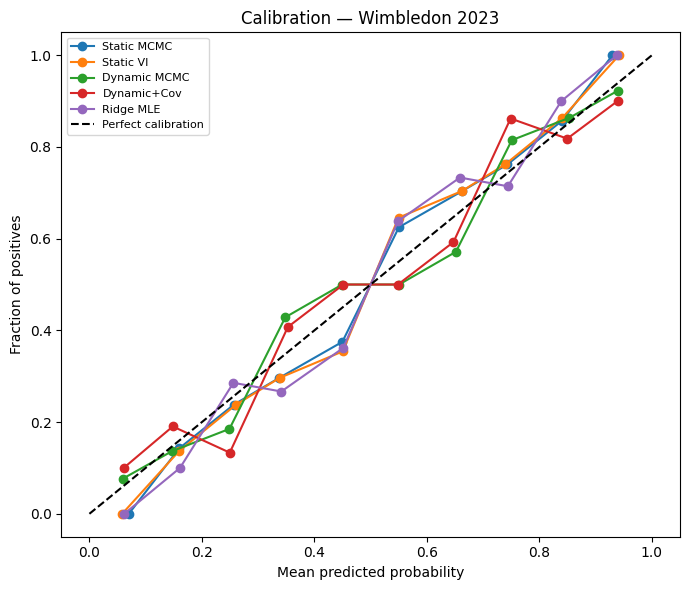


Covariate posterior summary:
                   mean     sd  hdi_3%  hdi_97%  ess_bulk  r_hat
intercept         0.000  0.015  -0.027    0.027    7321.0    1.0
surf_clay         0.000  0.015  -0.029    0.028    6873.0    1.0
surf_grass        0.000  0.015  -0.027    0.028    6621.0    1.0
surf_carpet      -0.000  0.488  -0.883    0.920    9484.0    1.0
best_of           0.000  0.015  -0.029    0.028    6542.0    1.0
rank_diff         0.050  0.038  -0.020    0.122    2450.0    1.0
rank_points_diff -1.037  0.124  -1.280   -0.809    1237.0    1.0
age_diff          0.501  0.125   0.263    0.738    1120.0    1.0
height_diff       0.423  0.136   0.162    0.660    1121.0    1.0

Diagnostics: dynamic model
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_init  0.922  0.068   0.784    1.045      0.002    0.001    1489.0   
sigma_rw    0.763  0.029   0.711    0.820      0.001    0.001     724.0   

            ess_tail  r_hat  
sigma_init    1887.0    1.0  
sigma_

In [16]:
# -----------------------------------------------------------------------------
# MAIN PIPELINE
# -----------------------------------------------------------------------------
def main():
    print("Loading data...")
    data = load_atp_data(YEARS, DATA_DIR)
    data = filter_players_by_min_matches(data, MIN_MATCHES_PER_PLAYER)
    data, encoding = encode_players_by_id(data)
    data, periods = assign_time_periods(data, freq=TIME_FREQ)

    train_df, test_df, cutoff_date = temporal_tournament_split(
        data,
        test_tournament=TEST_TOURNAMENT,
        test_year=TEST_YEAR,
    )

    n_players = len(encoding.player2idx)
    n_periods = len(periods)

    print(f"Total matches after filtering: {len(data):,}")
    print(f"Players: {n_players:,} | Periods: {n_periods}")
    print(f"Train matches: {len(train_df):,} | Test matches: {len(test_df):,}")
    print(f"Cutoff date: {cutoff_date.date()}")

    # Pairwise datasets
    train_pair = build_pairwise_dataset(train_df, train_reference_df=train_df)
    test_pair = build_pairwise_dataset(test_df, train_reference_df=train_df)

    covariate_cols = [
        "surf_clay", "surf_grass", "surf_carpet",
        "best_of",
        "rank_diff", "rank_points_diff", "age_diff", "height_diff",
    ]
    train_pair, test_pair, scaler_stats = standardize_covariates(train_pair, test_pair, covariate_cols)

    y_test = test_pair["y"].values.astype(int)

    # -------------------------
    # Static BT
    # -------------------------
    print("\nFitting static BT (MCMC)...")
    static_model = build_static_bt_model(train_pair, n_players)
    trace_static = fit_static_bt_mcmc(static_model)

    print("\nFitting static BT (VI)...")
    static_model_vi = build_static_bt_model(train_pair, n_players)
    approx_static = fit_static_bt_vi(static_model_vi)

    # -------------------------
    # Dynamic BT
    # -------------------------
    print("\nFitting dynamic BT (MCMC)...")
    dynamic_model = build_dynamic_bt_model(train_pair, n_players, n_periods)
    trace_dynamic = fit_static_bt_mcmc(dynamic_model)

    # -------------------------
    # Dynamic BT + covariates
    # -------------------------
    print("\nFitting dynamic BT + covariates (MCMC)...")
    dynamic_cov_model = build_dynamic_bt_covariate_model(train_pair, n_players, n_periods, covariate_cols)
    trace_dynamic_cov = fit_static_bt_mcmc(dynamic_cov_model)

    # -------------------------
    # Frequentist regularized BT
    # -------------------------
    print("\nFitting regularized BT MLE baseline...")
    theta_mle, mle_result = fit_bt_mle_ridge(train_pair, n_players=n_players, l2=2.0)
    print(f"MLE converged: {mle_result.success}")

    # -------------------------
    # Predictions
    # -------------------------
    print("\nGenerating predictions...")
    prob_static = predict_static_mcmc(trace_static, test_pair)
    prob_static_vi = predict_static_vi(approx_static, static_model_vi, test_pair)
    prob_dynamic = predict_dynamic_mcmc(trace_dynamic, test_pair)
    prob_dynamic_cov = predict_dynamic_covariate_mcmc(trace_dynamic_cov, test_pair, covariate_cols)
    prob_mle = predict_bt_mle(theta_mle, test_pair)

    # -------------------------
    # Evaluation
    # -------------------------
    print("\nEvaluation on strictly held-out event:")
    print(f"  Tournament: {TEST_TOURNAMENT} {TEST_YEAR}")
    results = pd.DataFrame([
        evaluate_predictions(y_test, prob_static, "Static BT — MCMC"),
        evaluate_predictions(y_test, prob_static_vi, "Static BT — VI"),
        evaluate_predictions(y_test, prob_dynamic, "Dynamic BT — MCMC"),
        evaluate_predictions(y_test, prob_dynamic_cov, "Dynamic BT + Covariates — MCMC"),
        evaluate_predictions(y_test, prob_mle, "Freq. BT — Ridge MLE"),
    ]).sort_values("log_loss")
    print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    plot_calibration_curves(
        y_test,
        {
            "Static MCMC": prob_static,
            "Static VI": prob_static_vi,
            "Dynamic MCMC": prob_dynamic,
            "Dynamic+Cov": prob_dynamic_cov,
            "Ridge MLE": prob_mle,
        },
        title=f"Calibration — {TEST_TOURNAMENT} {TEST_YEAR}",
    )

    # -------------------------
    # Covariate posterior summary
    # -------------------------
    print("\nCovariate posterior summary:")
    cov_summary = az.summary(trace_dynamic_cov, var_names=["intercept", "beta"])
    beta_names = {f"beta[{i}]": covariate_cols[i] for i in range(len(covariate_cols))}
    cov_summary = cov_summary.rename(index=beta_names)
    print(cov_summary[["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]].to_string())

    # -------------------------
    # Diagnostics
    # -------------------------
    print("\nDiagnostics: dynamic model")
    run_diagnostics(trace_dynamic, var_names=["sigma_init", "sigma_rw"])
    print("\nDiagnostics: dynamic covariate model")
    run_diagnostics(trace_dynamic_cov, var_names=["sigma_init", "sigma_rw", "intercept", "beta"])

    # -------------------------
    # Top players at test period
    # -------------------------
    test_period = int(test_df["period"].mode().iloc[0])
    theta_last = _flatten_theta_dynamic(trace_dynamic)[:, :, test_period].mean(axis=0)
    top_idx = np.argsort(theta_last)[::-1][:15]
    top_players = pd.DataFrame({
        "player": [encoding.idx2player_name[i] for i in top_idx],
        "player_id": [encoding.idx2player_id[i] for i in top_idx],
        "skill_mean": theta_last[top_idx],
    })
    print("\nTop players by posterior mean skill at test period:")
    print(top_players.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # -------------------------
    # Save outputs
    # -------------------------
    results.to_csv("evaluation_summary.csv", index=False)
    top_players.to_csv("top_players_test_period.csv", index=False)
    print("\nSaved: evaluation_summary.csv, top_players_test_period.csv")

    # -------------------------
    # Optional bracket simulation example
    # -------------------------
    # Replace this with the actual tournament draw if you have it.
    unique_test_players = pd.unique(pd.concat([test_df["winner_idx"], test_df["loser_idx"]]))
    unique_test_players = unique_test_players[:8]
    if len(unique_test_players) == 8:
        example_draw = [[int(unique_test_players[i]), int(unique_test_players[i + 1])] for i in range(0, 8, 2)]
        bracket_df = simulate_tournament_from_dynamic_trace(
            trace_dynamic,
            draw=example_draw,
            period_idx=test_period,
            idx2player_name=encoding.idx2player_name,
            n_simulations=3000,
        )
        bracket_df.to_csv("example_bracket_simulation.csv", index=False)
        print("\nExample bracket simulation:")
        print(bracket_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
        print("Saved: example_bracket_simulation.csv")
    else:
        print("\nSkipped example bracket simulation because fewer than 8 test players were available.")



    # -------------------------
    # Several tournament simulations + charts
    # -------------------------
    unique_test_players = pd.unique(pd.concat([test_df["winner_idx"], test_df["loser_idx"]]))
    candidate_skills = theta_last[unique_test_players]
    ranked_candidates = unique_test_players[np.argsort(candidate_skills)[::-1]]

    if len(ranked_candidates) >= 8:
        player_pool = [int(x) for x in ranked_candidates[:8]]
        multi_sim_df = simulate_multiple_tournament_scenarios(
            trace_dynamic,
            player_indices=player_pool,
            period_idx=test_period,
            idx2player_name=encoding.idx2player_name,
            n_scenarios=5,
            n_simulations=3000,
            random_seed=RANDOM_SEED,
        )
        multi_sim_df.to_csv("multiple_tournament_simulations.csv", index=False)
        plot_tournament_simulation_charts(multi_sim_df, output_prefix="multiple_tournament_simulations")

        title_summary = (
            multi_sim_df[["scenario", "player", "Title"]]
            .sort_values(["scenario", "Title"], ascending=[True, False])
            .groupby("scenario")
            .head(5)
        )

        print("Top title probabilities by scenario:")
        print(title_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
        print(
                    "Saved: multiple_tournament_simulations.csv, "
                    "multiple_tournament_simulations_title_probabilities.png, "
                    "multiple_tournament_simulations_avg_title_probability.png"
                )
    else:
      print("Skipped multi-scenario tournament simulation because fewer than 8 test players were available.")



# Run the pipeline
artifacts = main()